## Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader           
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import Counter
from tqdm.auto import tqdm

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We chose glove over word2vec as the pretrained model has larger vocab more robust, more reasons why here, over us training our own word2vec embedding with our limited sample of n<5000 

we chose the 6B model with 100 dimensions as we are running our models on local and our compute power is limited. 

In [2]:
# Load preprocessed data
train = pd.read_csv('train_preprocessed.csv')
test = pd.read_csv('test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Number of classes: 5


## Global Variables

In [3]:
batch_size = 32
embedding_dim = 100
num_epochs = 20
criterion = nn.CrossEntropyLoss()
lr = 0.01
torch.manual_seed(42)
np.random.seed(42)

## Build Vocab and Embeddings

In [4]:
def tokenize(text):
    return text.lower().split()
    
def build_vocab(texts):
    vocab = Counter()
    for text in texts:
        tokens = tokenize(text)
        vocab.update(tokens)
    return vocab

def load_glove_embeddings(glove_file, vocab, embedding_dim):
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf8') as f:
        for line in f:
            parts = line.strip().split()
            # skip any malformed lines
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings_index[word] = vector

    # Special tokens
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    pad_vec = np.zeros(embedding_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)

    # Build list of vectors
    embedding_list = [pad_vec, unk_vec]
    for word in sorted(vocab):
        word2idx[word] = len(word2idx)
        vec = embeddings_index.get(word)
        if vec is None:
            vec = np.random.normal(scale=0.6, size=(embedding_dim,)).astype(np.float32)
        embedding_list.append(vec)

    embedding_matrix = np.asarray(embedding_list, dtype=np.float32)  # shape: (vocab_size, embedding_dim)
    print("Embedding matrix shape:", embedding_matrix.shape)
    embedding_tensor = torch.from_numpy(embedding_matrix)      # dtype=torch.float32

    return word2idx, embedding_tensor, embeddings_index


We use simple white space tokenizer to use with glove which is word based to feed words sequentially into LSTM. 

In [5]:
def encode_text(texts, word2idx, max_len=100):
    encoded = []
    for text in texts:
        tokens = tokenize(text)
        idxs = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
        if len(idxs) < max_len:
            idxs += [word2idx['<PAD>']] * (max_len - len(idxs))
        else:
            idxs = idxs[:max_len]
        encoded.append(idxs)
    return torch.tensor(encoded)

In [6]:
vocab = build_vocab(train['cleaned_text'])        
embedding_dim = 100

word2idx, embedding_tensor, embeddings_index = load_glove_embeddings(glove_file, vocab, embedding_dim)

# check embedding match:
idx = word2idx.get('trump')
# check loaded embedding tensor directly
print("Loaded embedding tensor first 5 dims:", embedding_tensor[idx][:5])
# compare with original GloVe
print("Original GloVe vector first 5 dims:", embeddings_index['trump'][:5])

Embedding matrix shape: (29075, 100)
Loaded embedding tensor first 5 dims: tensor([-0.1573, -0.7550,  0.3684, -0.1896, -0.1690])
Original GloVe vector first 5 dims: [-0.15731 -0.75503  0.36845 -0.18958 -0.16896]


In [7]:
max_len = 100  # maximum number of tokens per article; adjust if needed

# Encode texts to fixed‑length index tensors
X_train = encode_text(train['cleaned_text'], word2idx, max_len)
X_test = encode_text(test['cleaned_text'], word2idx, max_len)

# Convert label arrays to torch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class EncodedTextDataset(Dataset):
    """Returns a tuple (encoded_text, label) for each item."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]

# Create dataset instances
train_dataset = EncodedTextDataset(X_train, y_train_tensor)
test_dataset = EncodedTextDataset(X_test, y_test_tensor)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 56 | Test batches: 14


## LSTM

In [8]:
class LSTMModule(nn.Module):
    def __init__(self,
                 embedding_tensor,
                 hidden_dim=128,
                 num_layers=1,
                 bidirectional=False,
                 dropout=0.3,
                 num_classes=5):            # adjust
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.size(1),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1),
                            num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)
        if self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            feat = h_n[-1]
        return self.fc(feat)

We do not train the glove embedding or SFT it for now by setting freeze=True and lock padding index so that padding stays at zero and cannot drift. 

In [10]:
import skorch
from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping
from torch.optim.lr_scheduler import ReduceLROnPlateau

net = NeuralNetClassifier(
    module=LSTMModule,
    module__embedding_tensor=embedding_tensor,
    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    batch_size=32,
    max_epochs=20,
    device=device,

    # 20 % stratified validation inside each CV fold
    train_split=ValidSplit(0.2, stratified=True),

    callbacks=[
        LRScheduler(policy=ReduceLROnPlateau,
                    monitor='valid_loss',  # now exists
                    factor=0.5,
                    patience=2,
                    verbose=True),
        EarlyStopping(monitor='valid_loss', patience=5)
    ],
)

In [11]:
X_np = X_train.numpy()          # shape (N, seq_len)
y_np = y_train_tensor.numpy()

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'module__hidden_dim':      randint(64, 257),          # 64–256
    'module__num_layers':      randint(1, 3),             # 1 or 2
    'module__bidirectional':   [False, True],
    'module__dropout':         uniform(0.1, 0.4),         # 0.1–0.5
    'lr':                      uniform(5e-4, 5e-3),       # 5e‑4…5.5e‑3
    'batch_size':              [16, 32, 64],
}

search = RandomizedSearchCV(
    net,
    param_distributions=param_dist,
    n_iter=25,                # increase if budget allows
    cv=3,                     # 3‑fold inner CV
    scoring='accuracy',       # or balanced_accuracy / f1_macro
    refit=True,               # keep best_ estimator
    verbose=2,
    n_jobs=1                  # GPU ⇒ keep at 1
)

search.fit(X_np, y_np)        # skorch handles GPU inside each fit

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.3921       0.5168        1.3469  0.0024  1.3386
      2        1.2956       0.5000        1.3287  0.0024  0.7227
      3        1.1893       0.4958        1.3745  0.0024  0.7109
      4        1.0168       0.4412        1.5365  0.0024  0.7030
      5        0.8638       0.4496        1.5400  0.0024  0.7087
      6        0.6998       0.3992        1.8636  0.0012  0.7085
Stopping since valid_loss has not improved in the last 5 epochs.
[CV] END batch_size=64, lr=0.0023884510268583122, module__bidirectional=False, module__dropout=0.26016873703941756, module__hidden_dim=219, module__num_layers=2; total time=   6.5s


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.4200       0.5168        1.3395  0.0024  0.7077
      2        1.3133       0.5168        1.3486  0.0024  0.7176
      3        1.2415       0.5126        1.3675  0.0024  0.7076
      4        1.1137       0.3866        1.5403  0.0024  0.7083
      5        0.9699       0.4286        1.5620  0.0012  0.7080
Stopping since valid_loss has not improved in the last 5 epochs.
[CV] END batch_size=64, lr=0.0023884510268583122, module__bidirectional=False, module__dropout=0.26016873703941756, module__hidden_dim=219, module__num_layers=2; total time=   4.4s


...

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.3547       0.5168        1.2613  0.0005  1.9256
      2        1.2068       0.5252        1.1751  0.0005  1.9070
      3        1.0940       0.5126        1.1261  0.0005  1.9093
      4        0.9947       0.5126        1.1138  0.0005  1.9095
      5        0.8715       0.5252        1.1507  0.0005  1.9017
      6        0.7494       0.5294        1.2527  0.0005  1.9035
      7        0.6293       0.5126        1.2843  0.0005  1.9046
      8        0.5220       0.5420        1.2506  0.0003  1.9142
Stopping since valid_loss has not improved in the last 5 epochs.
[CV] END batch_size=16, lr=0.0005193088691363869, module__bidirectional=True, module__dropout=0.13599526494989023, module__hidden_dim=246, module__num_layers=1; total time=  17.6s


/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        1.3100       0.5253        1.2087  0.0054  3.3254
      2        1.1226       0.5337        1.1581  0.0054  2.2266
      3        0.8852       0.5562        1.2663  0.0054  2.2310
      4        0.5833       0.5562        1.4704  0.0054  2.2289
      5        0.3636       0.5702        1.8584  0.0054  2.2192
      6        0.1643       0.5253        1.8790  0.0027  2.2288
Stopping since valid_loss has not improved in the last 5 epochs.


RandomizedSearchCV(cv=3,
                   estimator=NeuralNetClassifier(_params_to_validate={'module__embedding_tensor'}, batch_size=32, callbacks=[<skorch.callbacks.lr_scheduler.LRScheduler object at 0x16abee390>, <skorch.callbacks.training.EarlyStopping object at 0x1698e6870>], compile=False, criterion=<class 'torch.nn.modules.loss.CrossEntropyLoss'>, dataset=<class 'skorch.dat...
                                        'module__bidirectional': [False, True],
                                        'module__dropout': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x16a87a030>,
                                        'module__hidden_dim': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x313e6e390>,
                                        'module__num_layers': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x3369fcd70>},
                   scoring='accuracy', verbose=2)

In [ ]:
"""
<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTMModule(
    (embedding): Embedding(29075, 100, padding_idx=0)
    (lstm): LSTM(100, 147, num_layers=2, batch_first=True, dropout=0.12634803191578634, bidirectional=True)
    (fc): Linear(in_features=294, out_features=5, bias=True)
  ),
)
"""

In [17]:
best_net.save_params(f_params='lstm_best.pt')

## Evaluation

### Classification Report

In [15]:
from sklearn.metrics import classification_report
import torch

# 1. Grab the best fitted skorch model
best_net = search.best_estimator_

# 2. Make sure test data are NumPy arrays
X_test_np = X_test.cpu().numpy()          # (N, seq_len)
y_test_np = y_test_tensor.cpu().numpy()   # (N,)

# 3. Predict and print the report
y_pred = best_net.predict(X_test_np)
print(classification_report(
    y_test_np,
    y_pred,
    target_names=label_encoder.classes_, 
    digits=4))

              precision    recall  f1-score   support

      center     0.2759    0.2000    0.2319        40
   lean left     0.1857    0.2131    0.1985        61
  lean right     0.2174    0.1351    0.1667        37
        left     0.6492    0.7000    0.6736       230
       right     0.4000    0.3896    0.3947        77

    accuracy                         0.4876       445
   macro avg     0.3456    0.3276    0.3331       445
weighted avg     0.4731    0.4876    0.4784       445



### Confusion Matrices

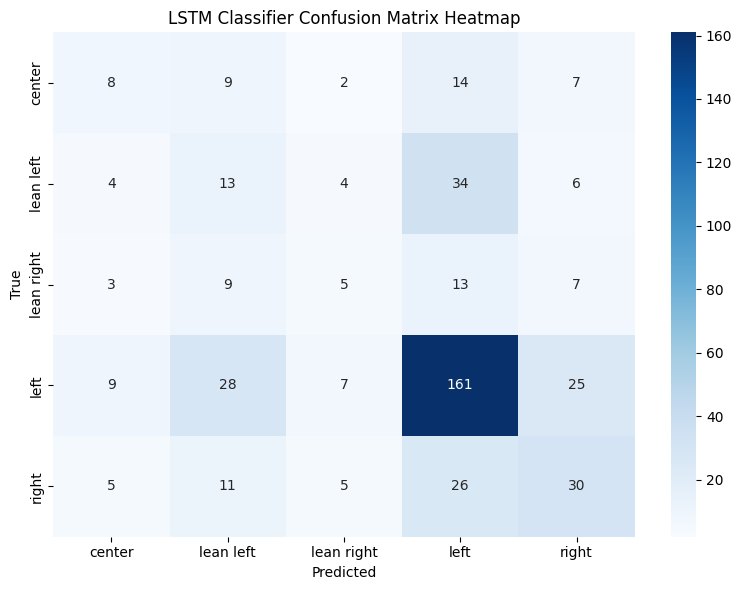

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predicted and true labels
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
y_pred = best_net.predict(X_test_np)

# 2. Get label names from the model (assuming label_encoder used during training)
labels = label_encoder.classes_

# 3. Compute confusion matrix with fixed label order
cm = confusion_matrix(y_test_np, y_pred, labels=np.arange(len(labels)))

# 4. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Classifier Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get the trained model and test data
best_net = search.best_estimator_
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

# 2. Get predictions
y_pred = best_net.predict(X_test_np)

# 3. Get class names
classes = best_net.classes_  # from skorch NeuralNetClassifier

# 4. Loop over each class for one-vs-rest confusion matrix
for i, class_label in enumerate(classes):
    y_true_binary = (y_test_np == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print(f"\nOne-vs-Rest Confusion Matrix for class '{class_label}':")
    print(cm)


One-vs-Rest Confusion Matrix for class '0':
[[384  21]
 [ 32   8]]

One-vs-Rest Confusion Matrix for class '1':
[[327  57]
 [ 48  13]]

One-vs-Rest Confusion Matrix for class '2':
[[390  18]
 [ 32   5]]

One-vs-Rest Confusion Matrix for class '3':
[[128  87]
 [ 69 161]]

One-vs-Rest Confusion Matrix for class '4':
[[323  45]
 [ 47  30]]


## ROC-AUC

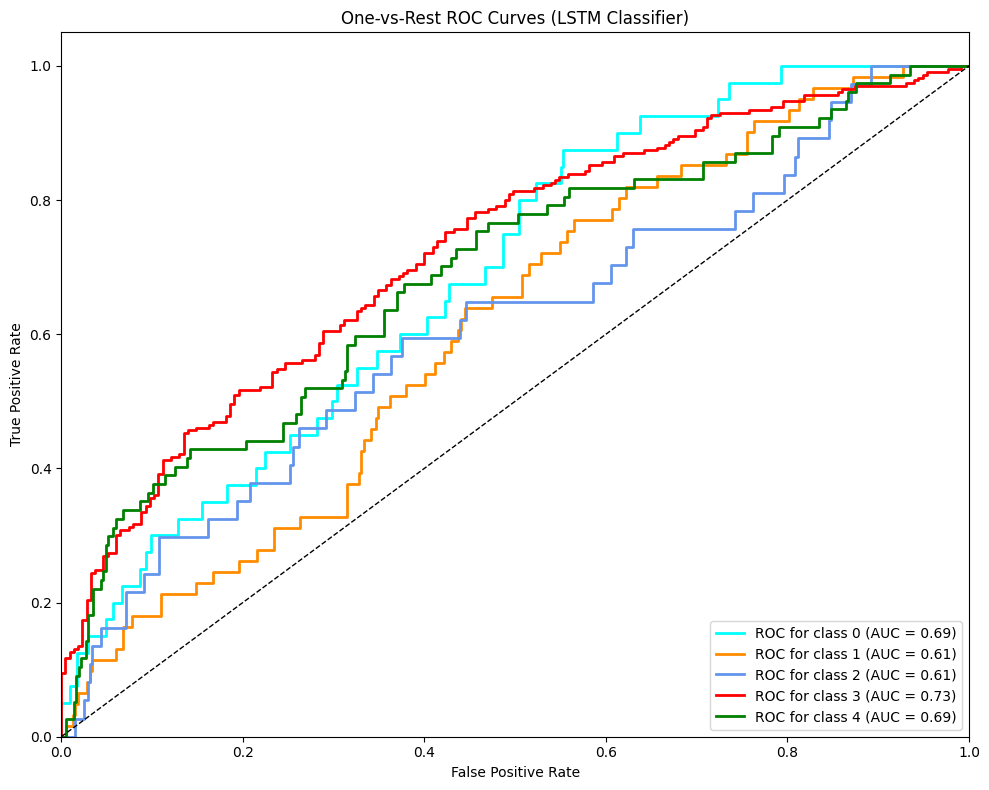

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the trained model and test data
best_net = search.best_estimator_
X_test_np = X_test.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()
classes = best_net.classes_

# 2. Binarize the true labels for One-vs-Rest
y_test_binarized = label_binarize(y_test_np, classes=range(len(classes)))

# 3. Get predicted probabilities
y_score = best_net.predict_proba(X_test_np)  # shape: (n_samples, n_classes)

# 4. Compute ROC curves and AUC for each class
fpr = {}
tpr = {}
roc_auc_dict = {}

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc_dict[c] = roc_auc_score(y_test_binarized[:, i], y_score[:, i])

# 5. Plot
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for c, color in zip(classes, colors):
    plt.plot(fpr[c], tpr[c], color=color, lw=2,
             label=f'ROC for class {c} (AUC = {roc_auc_dict[c]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves (LSTM Classifier)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [26]:
macro_auc = roc_auc_score(y_test_binarized, y_score, average='macro')
print(f"Macro-average ROC AUC: {macro_auc:.4f}")

Macro-average ROC AUC: 0.6650
